## Lab 3

### 1. Library Imports

In [3]:
#You may need to add other libraries here depending on your code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# to display plots in Jupyter notebook
%matplotlib inline

plt.rcParams['font.size'] = '12'

### 2. Reading the Data

In [4]:
df_train = pd.read_csv('training.csv')
df_test = pd.read_csv('testing.csv')

df_train_cleaned = df_train.iloc[:, :10]
df_test_cleaned = df_test.iloc[:, :10]

print(df_train_cleaned.columns)
print(df_test_cleaned.columns)

print(df_train_cleaned['class'].value_counts())
print(df_test_cleaned['class'].value_counts())

Index(['class', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9'], dtype='object')
Index(['class', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9'], dtype='object')
class
s    136
d    105
o     46
h     38
Name: count, dtype: int64
class
s    59
d    54
h    48
o    37
Name: count, dtype: int64


### 3. Data Preprocessing for Binary Classification

In [5]:
df_train_bin = df_train_cleaned[df_train_cleaned['class'].isin(['s', 'd'])].copy()
df_test_bin = df_test_cleaned[df_test_cleaned['class'].isin(['s', 'd'])].copy()

print(df_train_bin['class'].value_counts())
print(df_test_bin['class'].value_counts())

class
s    136
d    105
Name: count, dtype: int64
class
s    59
d    54
Name: count, dtype: int64


### 4. Split Data into Training an Validation sets  

In [6]:
from sklearn.model_selection import train_test_split

df_train_split, df_val_split = train_test_split(df_train_bin, test_size=0.2, random_state=42)

X_full = df_train.drop('class', axis=1)
y_full = df_train['class']

X = df_train_split.drop('class', axis=1)
y = df_train_split['class']

X_val = df_val_split.drop('class', axis=1)
y_val = df_val_split['class']

X_test = df_test_bin.drop('class', axis=1)
y_test = df_test_bin['class']

### 5. Find Optimal Value for Regularization & Learning Rate

In [14]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

# SGDClassifier uses 'alpha' for regularization strength (alpha = 1/C)
# and 'eta0' for the initial learning rate
param_grid = {
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 10, 100, 1000],   # regularization (1/C)
    'eta0':  [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0],   # learning rate η
    'learning_rate': ['constant']               # needed for eta0 to be used
}

sgd = SGDClassifier(penalty='l2', random_state=42)

grid_search = GridSearchCV(
    estimator=sgd,
    param_grid=param_grid,
    cv=10,              # 10-fold cross-validation
    scoring='accuracy',
)

grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'alpha': 0.1, 'eta0': 1e-05, 'learning_rate': 'constant'}
Best CV Accuracy: 0.9218421052631578


### 6. Model Trainin and Plot on Validation Set

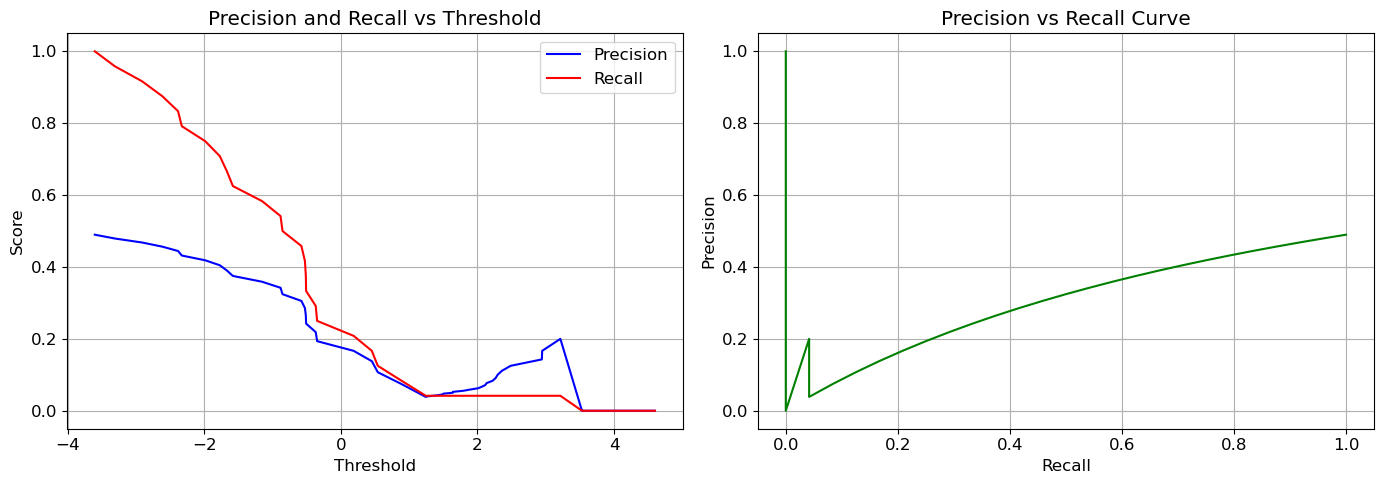

Optimal Threshold (max F1): -3.6040
  Precision at threshold:   0.4898
  Recall    at threshold:   1.0000
  F1 Score  at threshold:   1.4898


In [27]:
from sklearn.metrics import precision_recall_curve, accuracy_score
import matplotlib.pyplot as plt

best_params = grid_search.best_params_

final_model = SGDClassifier(
    penalty='l2',
    alpha=best_params['alpha'],
    eta0=best_params['eta0'],
    learning_rate=best_params['learning_rate'],
    random_state=42
)

final_model.fit(X, y)

y_scores = final_model.decision_function(X_val)

precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores, pos_label='d')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions[:-1], 'b-', label='Precision')
axes[0].plot(thresholds, recalls[:-1],    'r-', label='Recall')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision and Recall vs Threshold')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(recalls, precisions, 'g-')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision vs Recall Curve')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('precision_recall.png', dpi=150)
plt.show()

f1_scores = precisions + recalls
best_threshold_idx = f1_scores.argmax()
best_threshold     = thresholds[best_threshold_idx]

print(f"Optimal Threshold (max F1): {best_threshold:.4f}")
print(f"  Precision at threshold:   {precisions[best_threshold_idx]:.4f}")
print(f"  Recall    at threshold:   {recalls[best_threshold_idx]:.4f}")
print(f"  F1 Score  at threshold:   {f1_scores[best_threshold_idx]:.4f}")

### 7. Results

(a) Accuracy
    Training Accuracy : 0.9167
    Test Accuracy     : 0.9735


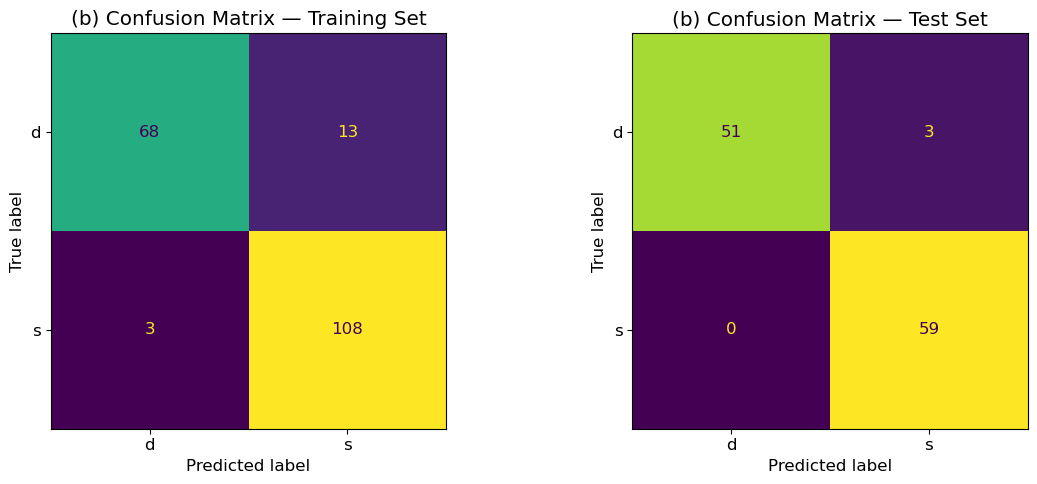

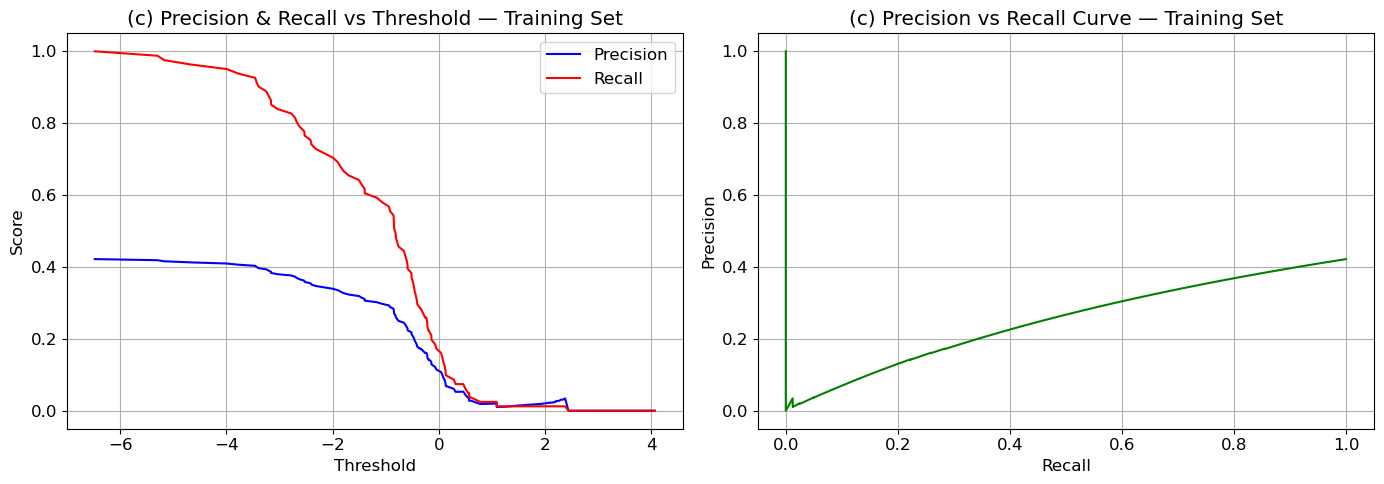

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import matplotlib.pyplot as plt

y_train_pred = final_model.predict(X)
y_test_pred  = final_model.predict(X_test)

train_accuracy = accuracy_score(y, y_train_pred)
test_accuracy  = accuracy_score(y_test, y_test_pred)

print("(a) Accuracy")
print(f"    Training Accuracy : {train_accuracy:.4f}")
print(f"    Test Accuracy     : {test_accuracy:.4f}")

cm_train = confusion_matrix(y, y_train_pred, labels=['d', 's'])
cm_test  = confusion_matrix(y_test, y_test_pred, labels=['d', 's'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train, display_labels=['d', 's']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('(b) Confusion Matrix — Training Set')

ConfusionMatrixDisplay(cm_test, display_labels=['d', 's']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('(b) Confusion Matrix — Test Set')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

y_train_scores = final_model.decision_function(X)

precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(
    y, y_train_scores, pos_label='d'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds_tr, precisions_tr[:-1], 'b-', label='Precision')
axes[0].plot(thresholds_tr, recalls_tr[:-1],    'r-', label='Recall')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('(c) Precision & Recall vs Threshold — Training Set')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(recalls_tr, precisions_tr, 'g-')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('(c) Precision vs Recall Curve — Training Set')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('precision_recall_train.png', dpi=150)
plt.show()

## 8. Extension

Best Parameters: {'alpha': 0.0001, 'eta0': 1e-05, 'learning_rate': 'constant'}
Best CV Accuracy: 0.9376315789473683


/tmp/ipykernel_11235/1827224468.py:96: RuntimeWarning: invalid value encountered in divide
  f1_scores_p    = 2 * (precisions_p[:-1] * recalls_p[:-1]) / (precisions_p[:-1] + recalls_p[:-1])


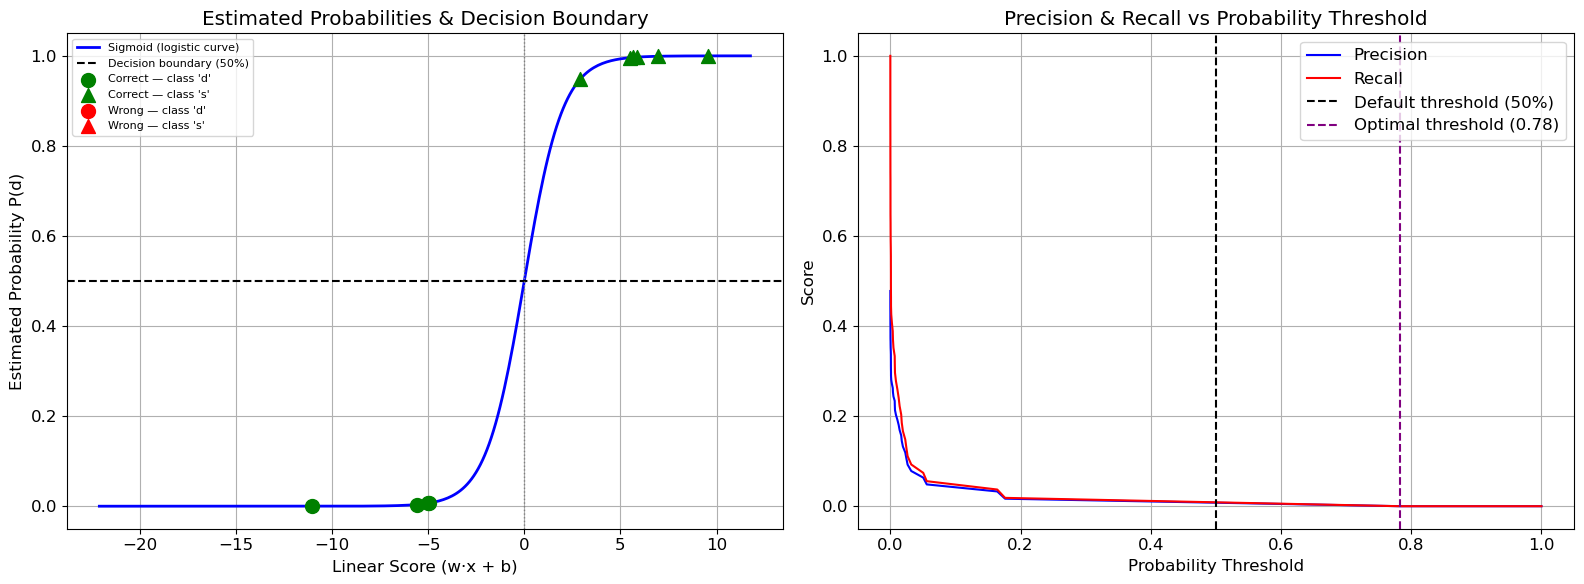


Optimal probability threshold : 0.7825
Default threshold (0.5) F1   : nan
Optimal threshold F1         : nan


In [30]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# ── Grid Search ───────────────────────────────────────────────────────────────
param_grid = {
    'alpha':         [0.0001, 0.001, 0.01, 0.1, 1.0, 10, 100, 1000],
    'eta0':          [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0],
    'learning_rate': ['constant']
}

sgd_lr = SGDClassifier(loss='log_loss', penalty='l2', tol=None, random_state=42)

grid_search_lr = GridSearchCV(
    estimator=sgd_lr,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_lr.fit(X, y)

print("Best Parameters:", grid_search_lr.best_params_)
print("Best CV Accuracy:", grid_search_lr.best_score_)

# ── Train final model with optimal params ─────────────────────────────────────
best_params_lr = grid_search_lr.best_params_

final_model_lr = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=best_params_lr['alpha'],
    eta0=best_params_lr['eta0'],
    learning_rate=best_params_lr['learning_rate'],
    tol=None,
    random_state=42
)

final_model_lr.fit(X, y)

# ── Compute linear scores and probabilities ───────────────────────────────────
# decision_function gives the raw linear score (w·x + b)
# predict_proba gives P(y='d' | x) using the sigmoid of the linear score
X_test_scores  = final_model_lr.decision_function(X_test)
X_test_proba   = final_model_lr.predict_proba(X_test)[:, 1]  # P(class='d')

X_train_scores = final_model_lr.decision_function(X)
X_train_proba  = final_model_lr.predict_proba(X)[:, 1]

# ── Smooth sigmoid curve across score range ───────────────────────────────────
score_range    = np.linspace(X_train_scores.min() - 1, X_train_scores.max() + 1, 300)
sigmoid_curve  = 1 / (1 + np.exp(-score_range))

# ── Randomly sample 10 test instances ────────────────────────────────────────
np.random.seed(42)
sample_idx     = np.random.choice(len(X_test), size=10, replace=False)
sample_scores  = X_test_scores[sample_idx]
sample_proba   = X_test_proba[sample_idx]
sample_true    = np.array(y_test)[sample_idx]
sample_pred    = final_model_lr.predict(X_test.iloc[sample_idx])
correct        = sample_true == sample_pred

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# — Plot 1: Estimated probabilities with decision boundary —
axes[0].plot(score_range, sigmoid_curve, 'b-', linewidth=2, label='Sigmoid (logistic curve)')
axes[0].axhline(y=0.5, color='k', linestyle='--', linewidth=1.5, label='Decision boundary (50%)')
axes[0].axvline(x=0,   color='gray', linestyle=':', linewidth=1)

for i in range(10):
    color  = 'green' if correct[i] else 'red'
    marker = 'o' if sample_true[i] == 'd' else '^'
    axes[0].scatter(sample_scores[i], sample_proba[i],
                    color=color, marker=marker, s=100, zorder=5)

axes[0].scatter([], [], color='green', marker='o', s=100, label="Correct — class 'd'")
axes[0].scatter([], [], color='green', marker='^', s=100, label="Correct — class 's'")
axes[0].scatter([], [], color='red',   marker='o', s=100, label="Wrong — class 'd'")
axes[0].scatter([], [], color='red',   marker='^', s=100, label="Wrong — class 's'")

axes[0].set_xlabel('Linear Score (w·x + b)')
axes[0].set_ylabel('Estimated Probability P(d)')
axes[0].set_title('Estimated Probabilities & Decision Boundary')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# — Plot 2: Precision-Recall vs Threshold (probability threshold) —
precisions_p, recalls_p, thresholds_p = precision_recall_curve(
    y_test, X_test_proba, pos_label='d'
)

f1_scores_p    = 2 * (precisions_p[:-1] * recalls_p[:-1]) / (precisions_p[:-1] + recalls_p[:-1])
best_thresh_p  = thresholds_p[f1_scores_p.argmax()]

axes[1].plot(thresholds_p, precisions_p[:-1], 'b-', label='Precision')
axes[1].plot(thresholds_p, recalls_p[:-1],    'r-', label='Recall')
axes[1].axvline(x=0.5,          color='k',      linestyle='--', label='Default threshold (50%)')
axes[1].axvline(x=best_thresh_p, color='purple', linestyle='--', label=f'Optimal threshold ({best_thresh_p:.2f})')
axes[1].set_xlabel('Probability Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs Probability Threshold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('logistic_boundary.png', dpi=150)
plt.show()

print(f"\nOptimal probability threshold : {best_thresh_p:.4f}")
print(f"Default threshold (0.5) F1   : {f1_scores_p[np.argmin(abs(thresholds_p - 0.5))]:.4f}")
print(f"Optimal threshold F1         : {f1_scores_p.max():.4f}")